In [2]:
# Electricity Load Forecasting

## Exploratory Data Analysis (EDA)

#This notebook performs the initial exploration of the electricity load dataset, including:

#- Data loading
#- Data inspection
#- Missing value analysis
#- Descriptive statistics
#- Visualization of electricity load patterns

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Plot style
plt.style.use("ggplot")

print("Electricity Load Forecasting Project")

Electricity Load Forecasting Project


In [4]:
import pandas as pd

df = pd.read_csv(
    "../data/time_series.csv"
)

df.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [5]:
df.shape
df.columns.tolist()

['utc_timestamp',
 'cet_cest_timestamp',
 'AT_load_actual_entsoe_transparency',
 'AT_load_forecast_entsoe_transparency',
 'AT_price_day_ahead',
 'AT_solar_generation_actual',
 'AT_wind_onshore_generation_actual',
 'BE_load_actual_entsoe_transparency',
 'BE_load_forecast_entsoe_transparency',
 'BE_solar_generation_actual',
 'BE_wind_generation_actual',
 'BE_wind_offshore_generation_actual',
 'BE_wind_onshore_generation_actual',
 'BG_load_actual_entsoe_transparency',
 'BG_load_forecast_entsoe_transparency',
 'BG_solar_generation_actual',
 'BG_wind_onshore_generation_actual',
 'CH_load_actual_entsoe_transparency',
 'CH_load_forecast_entsoe_transparency',
 'CH_solar_capacity',
 'CH_solar_generation_actual',
 'CH_wind_onshore_capacity',
 'CH_wind_onshore_generation_actual',
 'CY_load_actual_entsoe_transparency',
 'CY_load_forecast_entsoe_transparency',
 'CY_wind_onshore_generation_actual',
 'CZ_load_actual_entsoe_transparency',
 'CZ_load_forecast_entsoe_transparency',
 'CZ_solar_generation_

In [6]:
df_de = df[
    [
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency",
        "DE_solar_generation_actual",
        "DE_wind_generation_actual",
        "DE_wind_offshore_generation_actual"
    ]
].copy()

In [7]:
df_de.rename(
    columns={
        "utc_timestamp": "datetime",
        "DE_load_actual_entsoe_transparency": "load",
        "DE_solar_generation_actual": "solar",
        "DE_wind_generation_actual": "wind_onshore",
        "DE_wind_offshore_generation_actual": "wind_offshore"
    },
    inplace=True
)

In [8]:
df_de["datetime"] = pd.to_datetime(
    df_de["datetime"]
)

In [9]:
df_de.head()

,datetime,load,solar,wind_onshore,wind_offshore
0,2014-12-31 23:00:00+00:00,NaN,NaN,NaN,NaN
1,2015-01-01 00:00:00+00:00,41151.0,NaN,8852.0,517.0
2,2015-01-01 01:00:00+00:00,40135.0,NaN,9054.0,514.0
3,2015-01-01 02:00:00+00:00,39106.0,NaN,9070.0,518.0
4,2015-01-01 03:00:00+00:00,38765.0,NaN,9163.0,520.0


In [10]:
df_de.info()

<class 'pandas.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   datetime       50401 non-null  datetime64[us, UTC]
 1   load           50400 non-null  float64            
 2   solar          50297 non-null  float64            
 3   wind_onshore   50326 non-null  float64            
 4   wind_offshore  50326 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(4)
memory usage: 1.9 MB


In [11]:
df_de.isnull().sum()

datetime           0
load               1
solar            104
wind_onshore      75
wind_offshore     75
dtype: int64

In [12]:
df_de.to_csv(
    "../data/germany_energy.csv",
    index=False
)

In [13]:
df_de["datetime"].min(), df_de["datetime"].max()

(Timestamp('2014-12-31 23:00:00+0000', tz='UTC'),
 Timestamp('2020-09-30 23:00:00+0000', tz='UTC'))

In [14]:
#Time Features
df_de["hour"] = df_de["datetime"].dt.hour
df_de["day"] = df_de["datetime"].dt.day
df_de["month"] = df_de["datetime"].dt.month
df_de["weekday"] = df_de["datetime"].dt.dayofweek

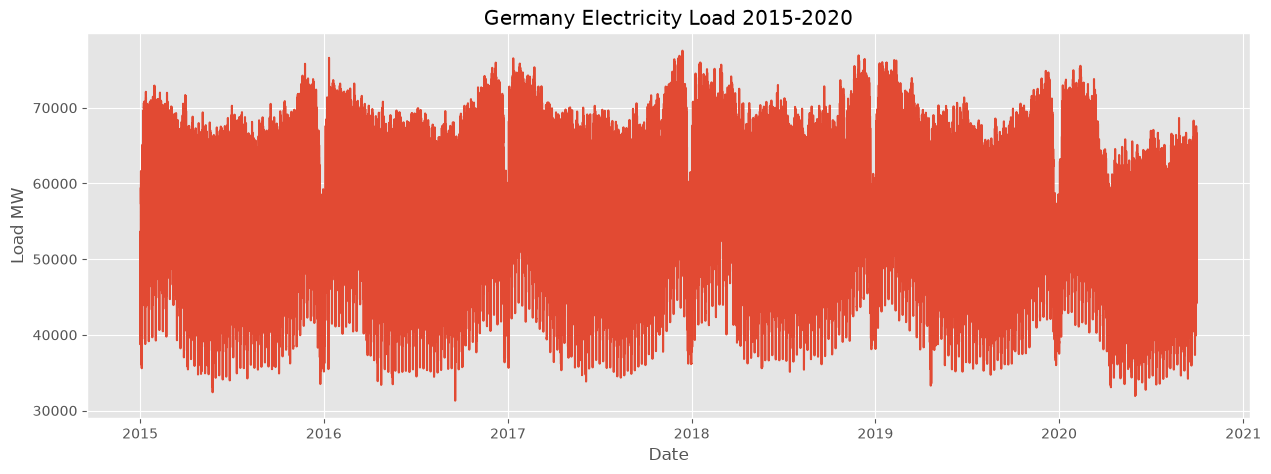

In [15]:
plt.figure(figsize=(15,5))

plt.plot(
    df_de["datetime"],
    df_de["load"]
)

plt.title("Germany Electricity Load 2015-2020")
plt.xlabel("Date")
plt.ylabel("Load MW")

plt.show()

In [16]:
df_de["datetime"].min(), df_de["datetime"].max()

(Timestamp('2014-12-31 23:00:00+0000', tz='UTC'),
 Timestamp('2020-09-30 23:00:00+0000', tz='UTC'))

In [18]:
df_de["datetime"] = df_de["datetime"].dt.tz_localize(None)

In [21]:
df_de["datetime"].dtype

dtype('<M8[us]')

In [22]:
df_de.to_csv(
    "../data/germany_energy.csv",
    index=False
)

In [23]:
df = pd.read_csv(
    "../data/germany_energy_weather.csv",
    parse_dates=["datetime"]
)

In [24]:
#Time Features
df["hour"] = df["datetime"].dt.hour

df["day"] = df["datetime"].dt.day

df["month"] = df["datetime"].dt.month

df["weekday"] = df["datetime"].dt.day_name()

df["weekend"] = (
    df["datetime"]
    .dt.dayofweek
    >= 5
)

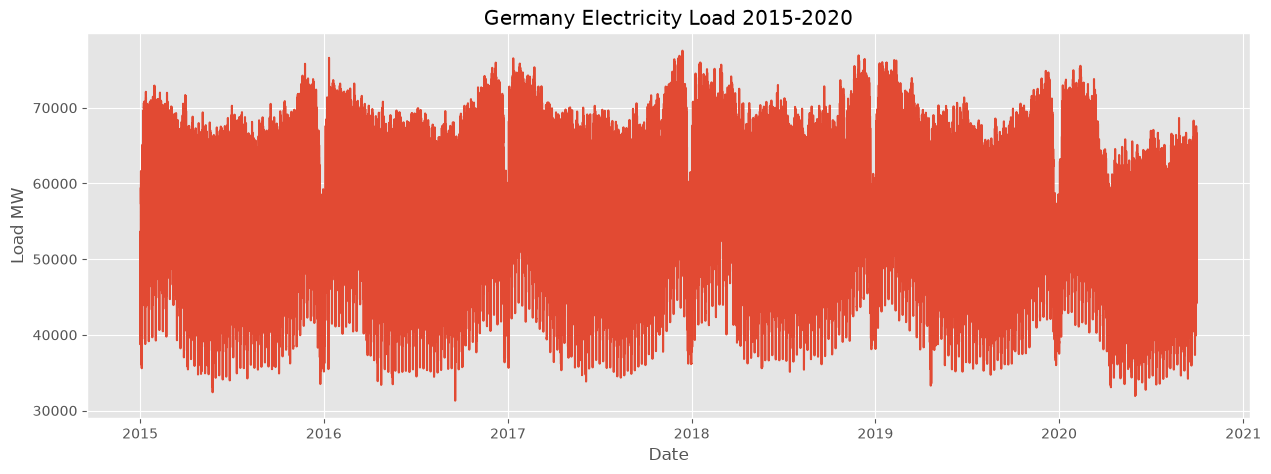

In [25]:
#How does the demand for electricity evolve over the years?
plt.figure(figsize=(15,5))

plt.plot(
    df["datetime"],
    df["load"]
)

plt.title(
    "Germany Electricity Load 2015-2020"
)

plt.xlabel("Date")
plt.ylabel("Load MW")

plt.show()

In [29]:
hourly_load = (
    df.groupby("hour")["load"]
    .mean()
)

hourly_load

hour
0     43882.047619
1     43553.034762
2     44133.652381
3     45950.040952
4     50131.535238
5     55042.064762
6     58897.579048
7     60921.150000
8     62353.457143
9     63640.790952
10    63733.839048
11    62800.928095
12    61518.203810
13    60384.280000
14    59498.595714
15    59598.973810
16    60662.533333
17    60974.783333
18    59544.625238
19    56794.175238
20    54039.865714
21    50915.867143
22    47596.083810
23    45251.138095
Name: load, dtype: float64

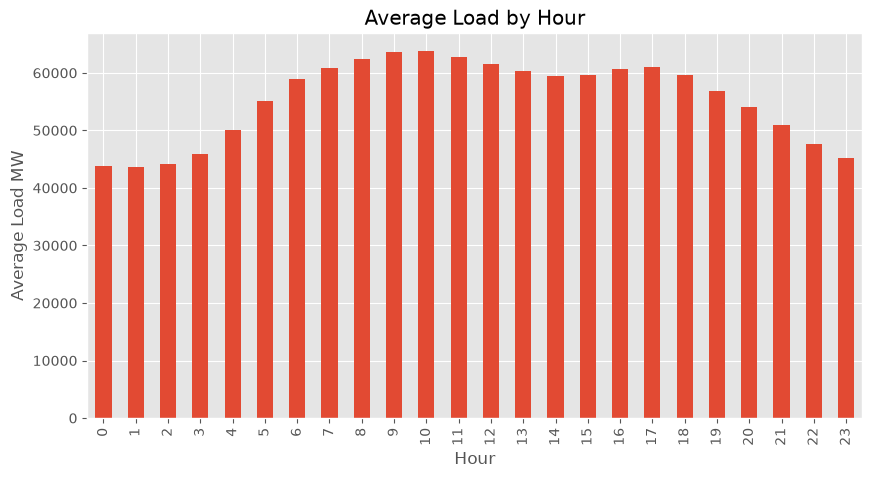

In [30]:
plt.figure(figsize=(10,5))

hourly_load.plot(
    kind="bar"
)

plt.title(
    "Average Load by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Average Load MW")

plt.show()

In [31]:
#Weekly Pattern
weekday_load = (
    df.groupby("weekday")["load"]
    .mean()
)

weekday_load

weekday
Friday       57742.414722
Monday       57522.666111
Saturday     49619.239861
Sunday       45902.455139
Thursday     58964.440278
Tuesday      59241.186667
Wednesday    59454.877083
Name: load, dtype: float64

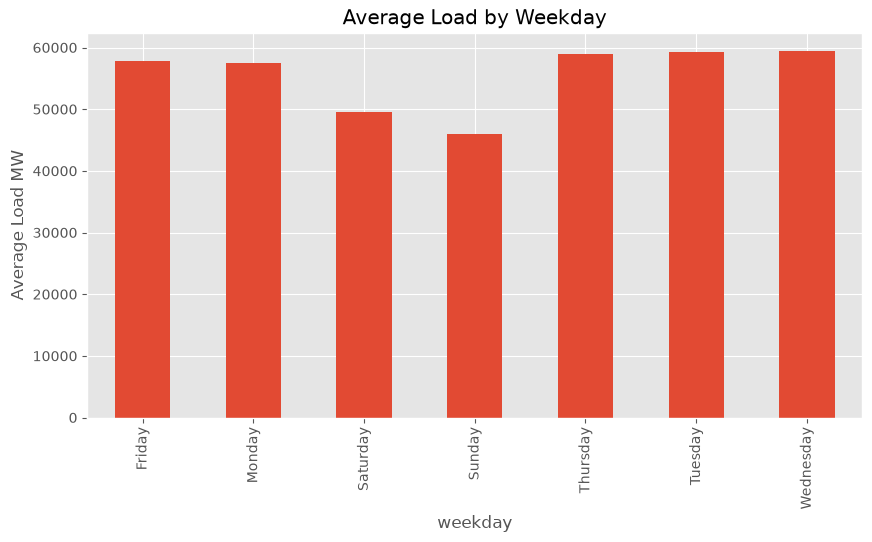

In [32]:
plt.figure(figsize=(10,5))

weekday_load.plot(
    kind="bar"
)

plt.title(
    "Average Load by Weekday"
)

plt.ylabel("Average Load MW")

plt.show()

In [33]:
#Monthly / Seasonal Pattern
monthly_load = (
    df.groupby("month")["load"]
    .mean()
)

monthly_load

month
1     59446.345430
2     59974.808088
3     57605.863127
4     53208.974769
5     52285.104167
6     53111.104630
7     53452.633961
8     52566.246192
9     53705.266667
10    55620.674194
11    59232.238889
12    56849.110215
Name: load, dtype: float64

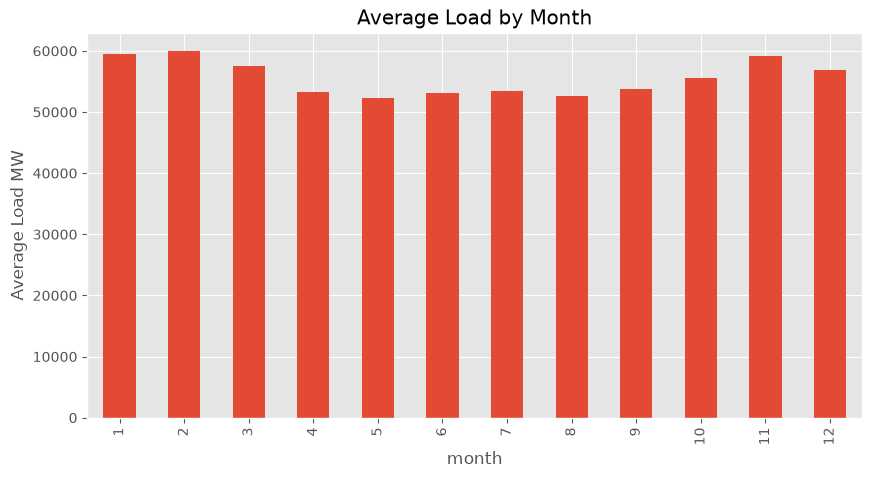

In [34]:
plt.figure(figsize=(10,5))

monthly_load.plot(
    kind="bar"
)

plt.title(
    "Average Load by Month"
)

plt.ylabel("Average Load MW")

plt.show()

In [35]:
df[["temperature", "load"]].corr()

,temperature,load
temperature,1.000000,-0.075669
load,-0.075669,1.000000


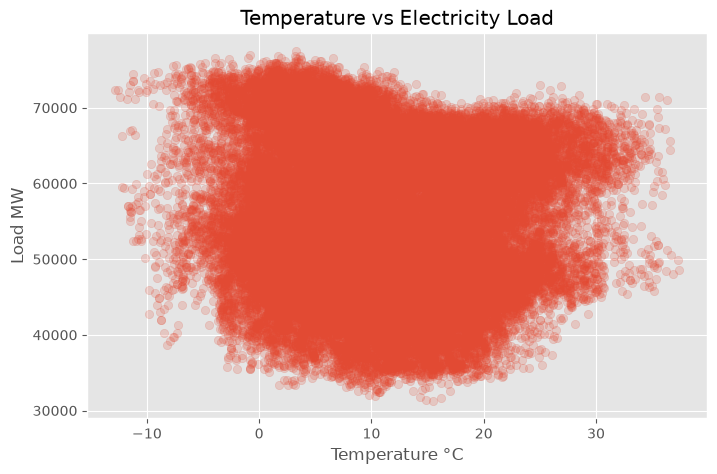

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["temperature"],
    df["load"],
    alpha=0.2
)

plt.xlabel("Temperature °C")
plt.ylabel("Load MW")
plt.title(
    "Temperature vs Electricity Load"
)

plt.show()

In [38]:
df["temp_group"] = pd.cut(
    df["temperature"],
    bins=[-20,0,10,20,30,50]
)

df.groupby("temp_group")["load"].mean()

temp_group
(-20, 0]    57604.153788
(0, 10]     56732.912045
(10, 20]    53049.436919
(20, 30]    56683.627154
(30, 50]    60219.422131
Name: load, dtype: float64

In [39]:
corr = df[
    [
        "load",
        "solar",
        "wind_onshore",
        "wind_offshore",
        "temperature",
        "wind_speed",
        "cloud_cover",
        "solar_radiation"
    ]
].corr()

corr["load"].sort_values(ascending=False)

load               1.000000
solar              0.312086
solar_radiation    0.290856
wind_speed         0.175109
cloud_cover        0.108138
wind_onshore       0.104717
wind_offshore      0.066719
temperature       -0.075669
Name: load, dtype: float64

In [ ]:
# Business Conclusions

## Electricity Load Patterns

#- Electricity demand shows strong hourly seasonality, with peak demand occurring during daytime working hours.
#- Weekdays have significantly higher demand compared with weekends, especially Wednesday and Tuesday.
#- Seasonal variations exist, with winter months showing higher electricity consumption.

## Weather Impact

#- Temperature has a nonlinear relationship with electricity demand.
#- Both cold and hot conditions increase demand due to heating and cooling requirements.
#- Moderate temperatures result in the lowest consumption levels.

## Feature Importance Expectations

#- Calendar features are expected to provide strong forecasting signals.
#- Weather variables should improve short-term forecasting accuracy.
#- Lag and rolling features will likely be critical for capturing demand dynamics.

## Final Conclusion

#The dataset is suitable for developing a 24-hour ahead electricity load forecasting model.